**Title of ML Project :** "Predicting Box Office Success : A Data Driven Analysis of Film Revenue Using Machine Learning"



---



**Name :** Chrissannah Mecanzie KJ

**Organization :** Entri Elevate

**Date :** 25/09/2024



---



**Step 1 :  Overview of the Problem Statement**

   The prime motive of this project is to predict the box office revenue of films using machine learning techniques by evaluating historical data, that includes variables such as budget, cast, genre and the release timing. The model helps to understand the pattern and the main factors that might influence a film's financial success. The challenge is in accurately forecasting revenue. This analysis will provide valuable insights for film producers and studios helping them make informed about the marketing strategies to maximize profitability.



**Step 2 : Objective**

   The objective of this project is to develop a machine learning model to accurately predict a film's box office revenue based on key factors such as budget, cast, genre, and release timing.

**Step 3 : Data Description**

  Source   -- data.world https://data.world/cye/update-movie-imdb

  Features  -- [Title,Budget,Genre,Director,Cast,Release date,Runtime,Production Company,Box office gross,IMDb rating,Metascore,Number of Screens,Country of origin,language,Marketing spend,Pre-release social media activity,Awards,Competition,Sequel or Original,Production Time]

**Step 4 : Data Collection**



-- Importing essential python libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV
import time
import joblib


-- Importing the dataset

In [2]:
from google.colab import files
upload =files.upload()

Saving movie_metadata (1).csv to movie_metadata (1).csv


In [3]:
df=pd.read_csv('movie_metadata (1).csv')

-- Insights

In [4]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [6]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [7]:
df.tail()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660
5042,Color,Jon Gunn,43.0,90.0,16.0,16.0,Brian Herzlinger,86.0,85222.0,Documentary,...,84.0,English,USA,PG,1100.0,2004.0,23.0,6.6,1.85,456


# **Step 5 : Data Preprocessing - Data Cleaning**



-- Finding missing values

In [8]:
df.isnull().sum()

,0
color,19
director_name,104
num_critic_for_reviews,50
duration,15
director_facebook_likes,104
actor_3_facebook_likes,23
actor_2_name,13
actor_1_facebook_likes,7
gross,884
genres,0


-- Handling missing values using appropriate imputation techniques.

Using KNN for numerical data

In [9]:
knn_imputer = KNNImputer(n_neighbors=5)

df[['budget', 'gross', 'duration','num_critic_for_reviews','title_year','director_facebook_likes','actor_3_facebook_likes','aspect_ratio']] = knn_imputer.fit_transform(df[['budget', 'gross', 'duration','num_critic_for_reviews','title_year','director_facebook_likes','actor_3_facebook_likes','aspect_ratio']])

*-- Using mode or 'Unknown' for Categorical data*

In [10]:
df['color'].fillna(df['color'].mode()[0],inplace=True)

<ipython-input-10-ae7e74a318d7>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['color'].fillna(df['color'].mode()[0],inplace=True)


In [11]:
df['director_name'].fillna('Unknown',inplace=True)

<ipython-input-11-6ef7d8fd6daa>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director_name'].fillna('Unknown',inplace=True)


In [12]:
df['actor_2_name'].fillna('Unknown',inplace=True)

<ipython-input-12-35115f809b1a>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['actor_2_name'].fillna('Unknown',inplace=True)


In [13]:
df['actor_3_name'].fillna('Unknown',inplace=True)

<ipython-input-13-b141d402ac62>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['actor_3_name'].fillna('Unknown',inplace=True)


In [14]:
df['actor_1_name'].fillna('Unknown',inplace=True)

<ipython-input-14-d156522623c7>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['actor_1_name'].fillna('Unknown',inplace=True)


In [15]:
df['plot_keywords'].fillna('Unknown',inplace=True)

<ipython-input-15-ba745f5ea965>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['plot_keywords'].fillna('Unknown',inplace=True)


In [16]:
df['content_rating'].fillna('Unknown',inplace=True)

<ipython-input-16-b824a2189b69>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['content_rating'].fillna('Unknown',inplace=True)


In [17]:
df['language'].fillna(df['language'].mode()[0],inplace=True)

<ipython-input-17-95bb342c0f53>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['language'].fillna(df['language'].mode()[0],inplace=True)


-- RobustScaler to handle outliers

In [18]:

robust_scaler = RobustScaler()

df[['budget', 'gross', 'duration', 'num_critic_for_reviews','num_critic_for_reviews','title_year','director_facebook_likes','actor_3_facebook_likes','aspect_ratio']] = robust_scaler.fit_transform(
    df[['budget', 'gross', 'duration', 'num_critic_for_reviews','num_critic_for_reviews','title_year','director_facebook_likes','actor_3_facebook_likes','aspect_ratio']]
)


*-- Identifying Outliers using IQR method*

In [19]:
def find_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers


# **Step 6 : Exploratory Data Analysis**

-- **Bar Plot** : *Compare counts of different categories*

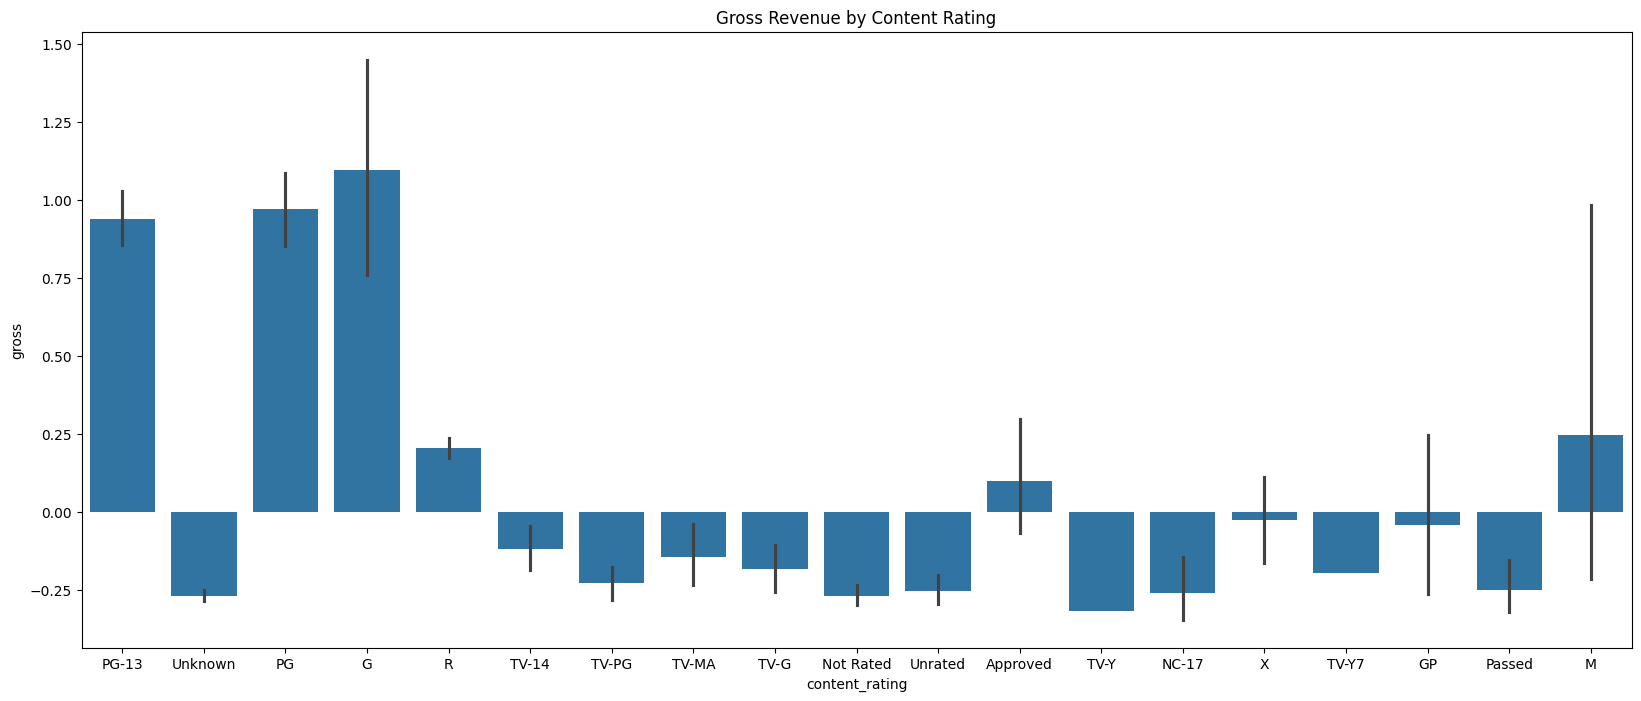

In [22]:
plt.figure(figsize=(20, 8))
sns.barplot(x='content_rating', y='gross', data=df)
plt.title('Gross Revenue by Content Rating')
plt.show()

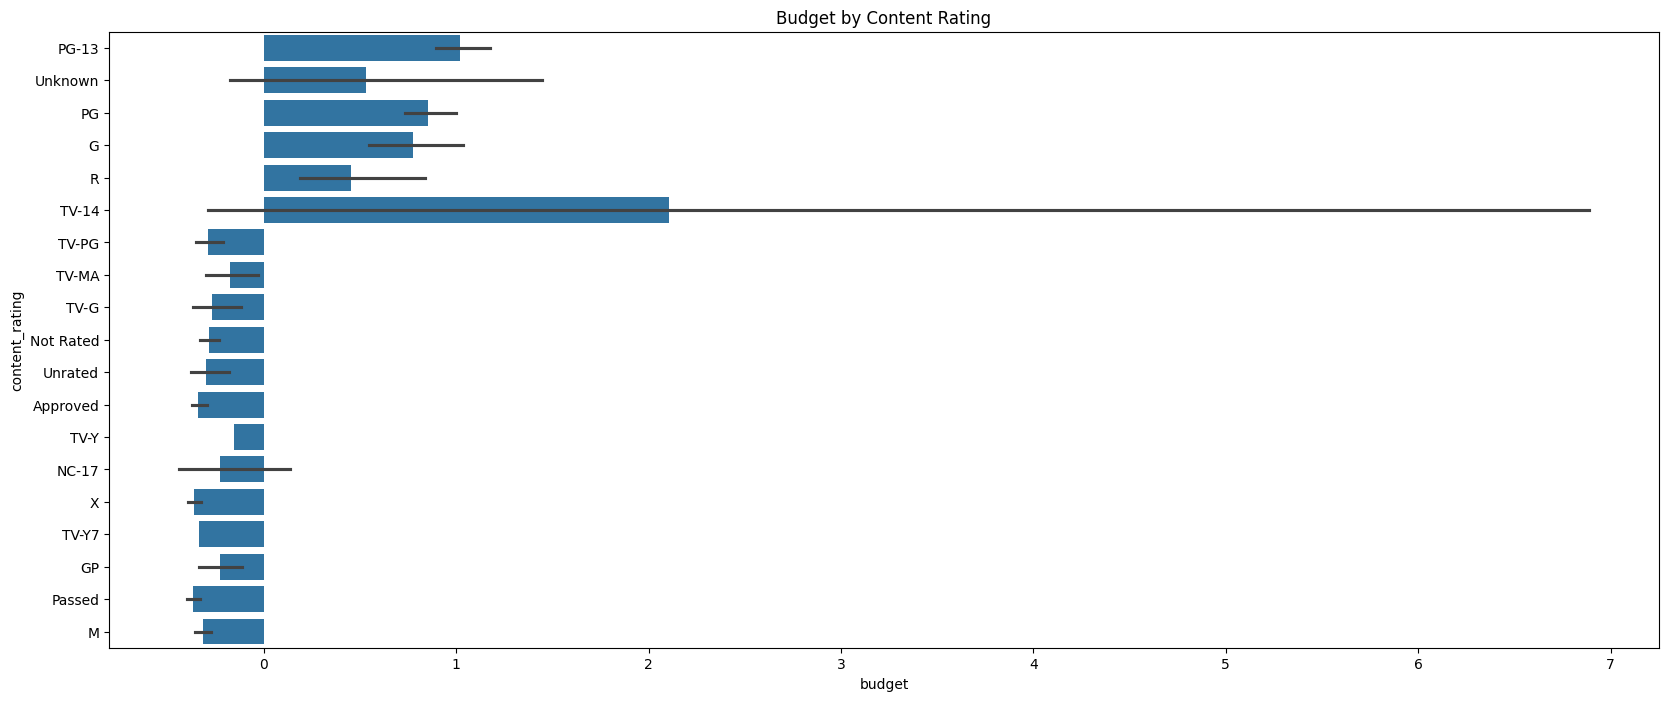

In [23]:
plt.figure(figsize=(20, 8))
sns.barplot(x='budget', y='content_rating', data=df)
plt.title('Budget by Content Rating')
plt.show()

-- **Count Plot** : *Count plot can visualize the frequency of categorical features*

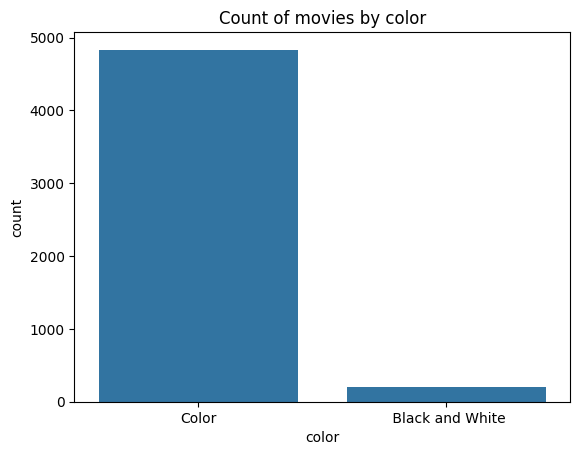

In [24]:
sns.countplot(x='color', data=df)
plt.title('Count of movies by color')
plt.show()

-- **Line plot** : *Visualize trends over time*

<Axes: title={'center': 'Gross Revenue by Year'}, xlabel='title_year'>

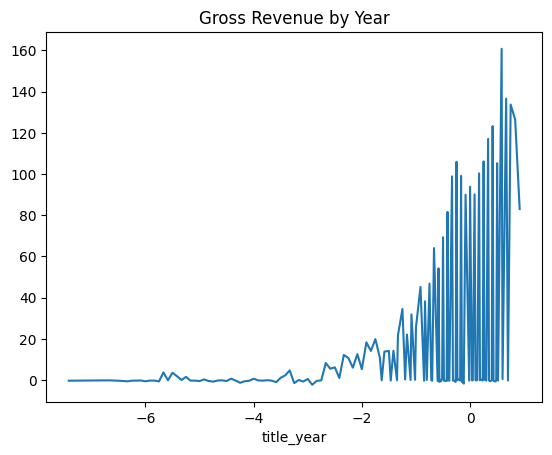

In [25]:
df.groupby('title_year')['gross'].sum().plot(kind='line', title='Gross Revenue by Year')

<Axes: title={'center': 'Gross Revenue by language'}, xlabel='language'>

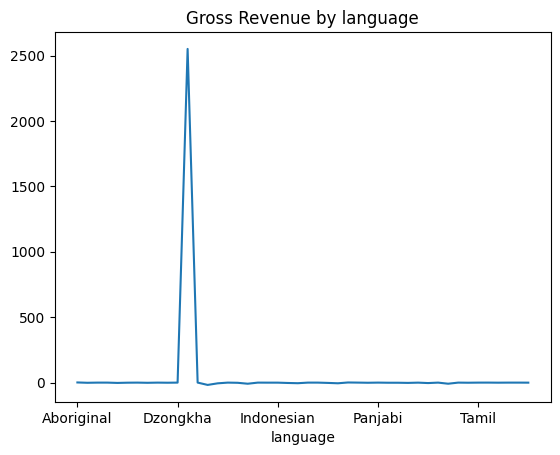

In [26]:
df.groupby('language')['gross'].sum().plot(kind='line', title='Gross Revenue by language')

<Axes: title={'center': 'Gross Revenue by country '}, xlabel='country'>

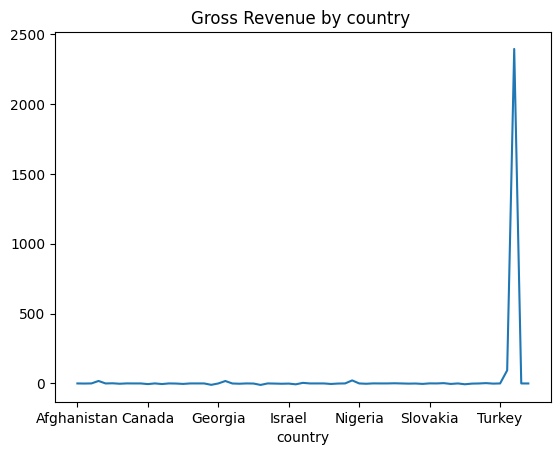

In [27]:
df.groupby('country')['gross'].sum().plot(kind='line', title='Gross Revenue by country ')

# **Step 7 : Feature Engineering**

*-- Label Encoding*

In [28]:
le = LabelEncoder()
df['content_rating_encoded'] = le.fit_transform(df['content_rating'])
print(df[['content_rating', 'content_rating_encoded']].head())

  content_rating  content_rating_encoded
0          PG-13                       7
1          PG-13                       7
2          PG-13                       7
3          PG-13                       7
4        Unknown                      16


In [29]:
print(df[['content_rating', 'content_rating']].tail())

     content_rating content_rating
5038        Unknown        Unknown
5039          TV-14          TV-14
5040        Unknown        Unknown
5041          PG-13          PG-13
5042             PG             PG


In [30]:
df_encoded = pd.get_dummies(df, columns=['content_rating'], drop_first=True)
print(df_encoded.head())

   color      director_name  num_critic_for_reviews  duration  \
0  Color      James Cameron                4.249135     3.000   
1  Color     Gore Verbinski                1.335640     2.640   
2  Color         Sam Mendes                3.411765     1.800   
3  Color  Christopher Nolan                4.871972     2.440   
4  Color        Doug Walker                0.597924     0.864   

   director_facebook_likes  actor_3_facebook_likes      actor_2_name  \
0                -0.263736                0.969154  Joel David Moore   
1                 2.829670                1.257711     Orlando Bloom   
2                -0.263736               -0.411940      Rory Kinnear   
3               120.615385               45.038806    Christian Bale   
4                 0.456044                4.791244        Rob Walker   

   actor_1_facebook_likes      gross                           genres  ...  \
0                  1000.0  15.315194  Action|Adventure|Fantasy|Sci-Fi  ...   
1                 40

*-- One-Hot Encoding*

In [31]:
X = df.drop(columns=['gross'])
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(X_encoded.head())

Categorical columns: Index(['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link',
       'language', 'country', 'content_rating'],
      dtype='object')
   num_critic_for_reviews  duration  director_facebook_likes  \
0                4.249135     3.000                -0.263736   
1                1.335640     2.640                 2.829670   
2                3.411765     1.800                -0.263736   
3                4.871972     2.440               120.615385   
4                0.597924     0.864                 0.456044   

   actor_3_facebook_likes  actor_1_facebook_likes  num_voted_users  \
0                0.969154                  1000.0           886204   
1                1.257711                 40000.0           471220   
2               -0.411940                 11000.0           275868   
3               45.038806                 27000.0          1144337   
4                4.79124

# **Step : 8 Feature Selection**

In [32]:
features = df[['director_name', 'actor_1_name', 'budget',
                'num_critic_for_reviews', 'gross',
                'movie_facebook_likes', 'genres',
                'imdb_score','cast_total_facebook_likes','content_rating']].copy()

target = df['gross']


for col in ['director_name', 'actor_1_name', 'genres', 'content_rating']:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        features[col] = le.fit_transform(features[col].fillna('Unknown'))


X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

selector = SelectKBest(f_regression, k=10)
selector.fit(X_train, y_train)


selected_features = X_train.columns[selector.get_support()]
print("Top 10 selected features:", selected_features)


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_10_features = feature_importances.nlargest(10)
print("Top 10 features based on importance:\n", top_10_features)

Top 10 selected features: Index(['director_name', 'actor_1_name', 'budget', 'num_critic_for_reviews',
       'gross', 'movie_facebook_likes', 'genres', 'imdb_score',
       'cast_total_facebook_likes', 'content_rating'],
      dtype='object')
Top 10 features based on importance:
 gross                        0.997705
num_critic_for_reviews       0.001044
actor_1_name                 0.000548
imdb_score                   0.000214
budget                       0.000170
movie_facebook_likes         0.000113
cast_total_facebook_likes    0.000094
director_name                0.000062
genres                       0.000043
content_rating               0.000007
dtype: float64


# **Step 9 : Splitting data into training and testing sets**

In [33]:
X = df.drop(columns=['gross'])
y = df['gross']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
print(f"Training set shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing set shape: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training set shape: X_train: (4034, 28), y_train: (4034,)
Testing set shape: X_test: (1009, 28), y_test: (1009,)


# **Step 10 : Feature Scaling**

In [36]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

In [37]:
X = df.drop(columns=['gross'])
y = df['gross']

In [38]:
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

In [39]:
X = pd.get_dummies(X, drop_first=True)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [41]:
X_train_min_max = min_max_scaler.fit_transform(X)
X_test_min_max = min_max_scaler.transform(X_test)

In [42]:
X_train_standardized = standard_scaler.fit_transform(X_train)
X_test_standardized = standard_scaler.transform(X_test)

In [43]:
print("Min-Max Scaled Training Features:", X_train_min_max.shape)
print("Min-Max Scaled Testing Features:", X_test_min_max.shape)
print("Standardized Training Features:", X_train_standardized.shape)
print("Standardized Testing Features:", X_test_standardized.shape)

Min-Max Scaled Training Features: (5043, 26699)
Min-Max Scaled Testing Features: (1009, 26699)
Standardized Training Features: (4034, 26699)
Standardized Testing Features: (1009, 26699)


# **Step 11 : Build the ML models**

*-- 1. Linear Regression*

In [44]:

lr = LinearRegression()
lr.fit(X_train_standardized, y_train)
y_pred = lr.predict(X_test_standardized)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression - RMSE: {rmse:.2f}, R²: {r2:.2f}")

Linear Regression - RMSE: 1.25, R²: 0.32


*-- 2. Random Forest Regression*

In [45]:

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train_standardized, y_train)
y_pred = rfr.predict(X_test_standardized)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest Regressor - RMSE: {rmse:.2f}, R²: {r2:.2f}")

Random Forest Regressor - RMSE: 0.76, R²: 0.75


*-- 3.MLP Regressor*

In [46]:
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
mlp.fit(X_train_standardized, y_train)
y_pred = mlp.predict(X_test_standardized)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MLP Regressor - RMSE: {rmse:.2f}, R²: {r2:.2f}")

MLP Regressor - RMSE: 1.44, R²: 0.10


*-- 4. Gradient Boosting Regressor*

In [47]:
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_train_standardized, y_train)
y_pred = gbr.predict(X_test_standardized)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Gradient Boosting Regressor - RMSE: {rmse:.2f}, R²: {r2:.2f}")

Gradient Boosting Regressor - RMSE: 0.77, R²: 0.74


*-- 5. Ada Boost Regressor*

In [48]:
abr = AdaBoostRegressor(n_estimators=100, random_state=42)
abr.fit(X_train_standardized, y_train)
y_pred_ada = abr.predict(X_test_standardized)
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mse_ada)
r2_ada = r2_score(y_test, y_pred_ada)
print(f"AdaBoost Regressor - RMSE: {rmse_ada:.2f}, R²: {r2_ada:.2f}")

AdaBoost Regressor - RMSE: 1.05, R²: 0.52


# **Step 12 : Model Evaluation**

*-- For Gradient Booster Regressor*

In [49]:

y_pred = gbr.predict(X_test_standardized)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error (MAE): 0.43
Mean Squared Error (MSE): 0.59
Root Mean Squared Error (RMSE): 0.77
R² Score: 0.74


*-- For Random Forest Regressor*

In [50]:

y_pred = rfr.predict(X_test_standardized)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error (MAE): 0.39
Mean Squared Error (MSE): 0.58
Root Mean Squared Error (RMSE): 0.76
R² Score: 0.75


*-- For Linear Regression*

In [51]:

y_pred = lr.predict(X_test_standardized)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error (MAE): 0.69
Mean Squared Error (MSE): 1.55
Root Mean Squared Error (RMSE): 1.25
R² Score: 0.32


*-- For AdaBoost Regressor*

In [52]:

y_pred = abr.predict(X_test_standardized)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error (MAE): 0.83
Mean Squared Error (MSE): 1.09
Root Mean Squared Error (RMSE): 1.05
R² Score: 0.52


*-- For MLP*

In [53]:

y_pred = mlp.predict(X_test_standardized)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error (MAE): 1.07
Mean Squared Error (MSE): 2.06
Root Mean Squared Error (RMSE): 1.44
R² Score: 0.10


# **Step 13: Hyperparameter Tuning**

In [54]:
model = RandomForestRegressor(random_state=42)
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist,
                                   n_iter=10, scoring='neg_mean_squared_error',
                                   cv=3, verbose=2, n_jobs=-1, random_state=42)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print(f"Best Hyperparameters: {best_params}")

best_model = random_search.best_estimator_


y_pred = best_model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Hyperparameters: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
R² Score: 0.75


# **Step 14 : Save the model**

In [55]:
import joblib
joblib.dump(best_model, 'random_forest_best_model.pkl')

print("Model saved successfully!")



Model saved successfully!


# **Step 15 : Test with unseen data**

In [56]:
from google.colab import files
upload =files.upload()

Saving insurance.csv to insurance.csv


In [57]:
unseen_df=pd.read_csv('insurance.csv')

In [58]:
unseen_df.fillna(unseen_df.median(numeric_only=True), inplace=True)

categorical_cols = unseen_df.select_dtypes(include=['object']).columns
unseen_df_encoded = pd.get_dummies(unseen_df, columns=categorical_cols, drop_first=True)

model = joblib.load('random_forest_best_model.pkl')

trained_model_columns = model.feature_names_in_

for col in trained_model_columns:
    if col not in unseen_df_encoded.columns:
        unseen_df_encoded[col] = 0

unseen_df_encoded = unseen_df_encoded[trained_model_columns]

predictions = model.predict(unseen_df_encoded)

print(predictions)

Streaming output truncated to the last 5000 lines.
<ipython-input-58-da8ac953bfdb>:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  unseen_df_encoded[col] = 0
<ipython-input-58-da8ac953bfdb>:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  unseen_df_encoded[col] = 0
<ipython-input-58-da8ac953bfdb>:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-

[-0.08406809 -0.08406809 -0.08406809 ... -0.08406809 -0.08406809
 -0.08406809]


# **Step 16 : Interpretation of Results (Conclusion)**

***--Model Performance (Random Forest)***

In the conclusion after training and evaluating models (Random Forest,Linear Regression,Ada Boost Regressor,MLP Regressor,Gradient Boosting Regressor) The Random Forest Regressor performs the best across all metrics, with the lowest MAE, MSE, and RMSE and the highest R² score (0.75).Random Forest also balances training time and scalability better than any other models trained.Therefore, Random Forest is concluded to be the best model for this regression project

***--Dataset Limitations***

Missing values - Several important features were missing such as budget, content rating etc.But these missing values were managed using imputation techniques (median,mode)

Other limitations was also there such as outliers and categorical variables which were difficult to manage without removing important datapoints also categorical variables were managed by one-hot encoding



***--Challenges Faced***

Feature encoding - Dealing with a large number of categorical variable was complex.This increased the time taken for both training and hyperparameter tuning.

Computational Time - Hyperparameter tuning took a considerable amount of time due to the size of the dataset and high dimentionality after encoding.






***--Conclusion***

In this project, multiple machine learning models were implemented to predict the gross revenue of films using various features from the dataset. After evaluating different models, Random Forest Regressordemonstrated the best performance.Despite these difficulties, the results indicate that with further data refinement and model tuning, accurate predictions of movie gross revenue can be achieved.

